# ILP Model on IBM HR Attrition

This notebook contains my ILP model for the IBM-HR attrition dataset.

The main aim is to learn readable rules for employee attrition. I first change the employee data into simple symbolic values, such as overtime = yes, income = low, and job satisfaction = low. Then I use a FOIL-style ILP rule learner to find patterns linked to employees leaving.

I kept this notebook focused on the model, outputs, visuals, and Prolog/Aleph-style file export.

In [ ]:
# 1. Imports and setup

import json
import math
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# File paths
TRAIN_PATH = Path("train_data_ibm.csv")
TEST_PATH = Path("test_data_ibm.csv")

# Fallback paths for this ChatGPT / Colab-style environment
if not TRAIN_PATH.exists():
    TRAIN_PATH = Path("/mnt/data/train_data_ibm.csv")
if not TEST_PATH.exists():
    TEST_PATH = Path("/mnt/data/test_data_ibm.csv")

OUTPUT_DIR = Path("ilp_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model settings
RANDOM_STATE = 42
TARGET_COL = "Attrition"

MAX_RULES = 10
MAX_LITERALS = 4
MIN_POSITIVE_COVERAGE = 3
MIN_RULE_PRECISION = 0.20
INCLUDE_BINARY_NO_LITERALS = False

print("Setup completed.")
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Output directory:", OUTPUT_DIR.resolve())

Setup completed.
Train path: /mnt/data/train_data_ibm.csv
Test path: /mnt/data/test_data_ibm.csv
Output directory: /content/ilp_outputs


In [ ]:
# 2. Load data

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

assert TARGET_COL in train_df.columns, "Attrition column not found in train data."
assert TARGET_COL in test_df.columns, "Attrition column not found in test data."

display(train_df.head())

Train shape: (1176, 44)
Test shape: (294, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,1.090194,1.049455,-0.899915,4,2,4,4,2,2.026752,0,...,1,0,0,0,0,0,1,0,0,0
1,-1.634828,-0.523449,-0.899915,1,3,3,1,4,-0.864408,0,...,0,0,0,0,0,0,0,1,0,0
2,0.981193,-0.992080,-0.777610,1,1,3,4,3,2.347706,0,...,1,0,0,0,0,0,0,1,0,0
3,-1.307825,-0.453653,0.445433,1,2,3,1,3,-0.956202,0,...,0,0,0,0,0,1,0,1,0,0
4,0.654191,0.491086,-0.043784,5,4,3,2,3,-0.185956,1,...,0,0,0,0,0,0,1,0,0,0


## Quick data check

Before training the ILP model, I checked the target distribution and basic data quality. This is mainly to make sure the train and test files are loaded correctly and that the attrition class balance is clear.

Train missing values: 0
Test missing values: 0


,train_count,test_count,train_percent,test_percent
Attrition,,,,
No Attrition,986,247,83.84,84.01
Attrition,190,47,16.16,15.99


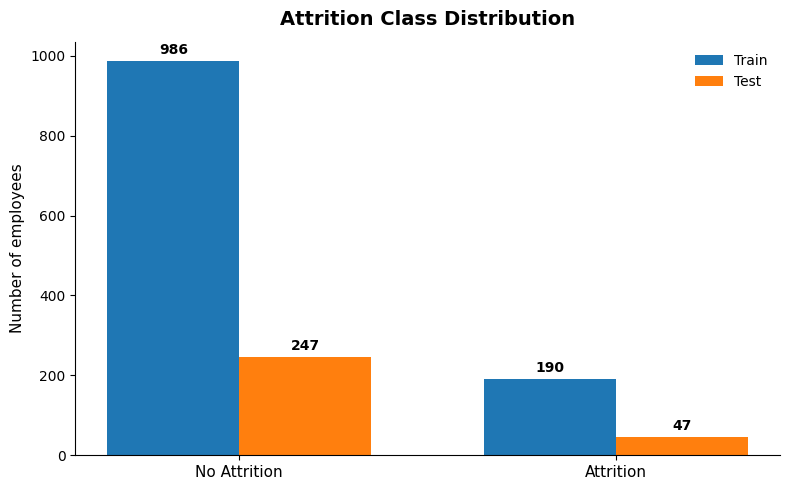

In [ ]:
# 3. Data audit and target visualisation

print("Train missing values:", train_df.isna().sum().sum())
print("Test missing values:", test_df.isna().sum().sum())

train_counts = train_df[TARGET_COL].value_counts().sort_index()
test_counts = test_df[TARGET_COL].value_counts().sort_index()

summary_df = pd.DataFrame({
    "train_count": train_counts,
    "test_count": test_counts,
    "train_percent": train_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100,
    "test_percent": test_df[TARGET_COL].value_counts(normalize=True).sort_index() * 100
}).rename(index={0: "No Attrition", 1: "Attrition"})

summary_df = summary_df.round(2)
display(summary_df)

labels = ["No Attrition", "Attrition"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_counts.values, width, label="Train")
bars2 = ax.bar(x + width/2, test_counts.values, width, label="Test")

ax.set_title("Attrition Class Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Number of employees", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + max(train_counts.max(), test_counts.max()) * 0.01,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Convert the data into symbols

ILP works better when the data is represented as simple symbols. Here, numeric columns are changed into bands such as very low, low, medium, and high. Binary columns are changed into yes/no values. This makes the later rules easier to read.

In [ ]:
# 4. Symbolic conversion helpers

def clean_atom(value):
    value = str(value).lower().strip()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    if value == "":
        value = "missing"
    if re.match(r"^\d", value):
        value = "v_" + value
    return value


def clean_predicate_name(col):
    return clean_atom(col)


def make_feature_metadata(train_df, target_col=TARGET_COL):
    metadata = {}

    for col in train_df.columns:
        if col == target_col:
            continue

        s = train_df[col]
        values = set(s.dropna().unique().tolist())

        if values.issubset({0, 1}) and len(values) <= 2:
            metadata[col] = {"type": "binary"}

        elif pd.api.types.is_numeric_dtype(s) and s.nunique() <= 10:
            metadata[col] = {
                "type": "ordinal",
                "values": sorted(s.dropna().unique().tolist())
            }

        elif pd.api.types.is_numeric_dtype(s):
            q25, q50, q75 = s.quantile([0.25, 0.50, 0.75]).tolist()
            metadata[col] = {
                "type": "numeric",
                "thresholds": {
                    "q25": float(q25),
                    "q50": float(q50),
                    "q75": float(q75)
                }
            }

        else:
            metadata[col] = {
                "type": "categorical",
                "values": sorted(s.dropna().astype(str).unique().tolist())
            }

    return metadata


def value_to_symbol(value, spec):
    if pd.isna(value):
        return "missing"

    if spec["type"] == "numeric":
        q25 = spec["thresholds"]["q25"]
        q50 = spec["thresholds"]["q50"]
        q75 = spec["thresholds"]["q75"]

        if value <= q25:
            return "very_low"
        elif value <= q50:
            return "low"
        elif value <= q75:
            return "medium"
        else:
            return "high"

    if spec["type"] == "ordinal":
        try:
            return f"level_{int(value)}"
        except Exception:
            return clean_atom(value)

    if spec["type"] == "binary":
        return "yes" if int(value) == 1 else "no"

    return clean_atom(value)


def symbolic_transform(df, metadata, target_col=TARGET_COL):
    sym = pd.DataFrame(index=df.index)

    for col, spec in metadata.items():
        sym[col] = df[col].apply(lambda x: value_to_symbol(x, spec)).astype(str)

    sym["target"] = df[target_col].astype(int).values
    return sym

In [ ]:
# 5. Fit symbolic conversion on training data and apply it to train/test

metadata = make_feature_metadata(train_df, target_col=TARGET_COL)

train_sym = symbolic_transform(train_df, metadata, target_col=TARGET_COL)
test_sym = symbolic_transform(test_df, metadata, target_col=TARGET_COL)

display(train_sym.head())

with open(OUTPUT_DIR / "symbolic_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved symbolic metadata.")

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,target
0,high,high,very_low,level_4,level_2,level_4,level_4,level_2,high,no,...,yes,no,no,no,no,no,yes,no,no,0
1,very_low,low,very_low,level_1,level_3,level_3,level_1,level_4,very_low,no,...,no,no,no,no,no,no,no,yes,no,0
2,high,very_low,low,level_1,level_1,level_3,level_4,level_3,high,no,...,yes,no,no,no,no,no,no,yes,no,0
3,very_low,low,medium,level_1,level_2,level_3,level_1,level_3,very_low,no,...,no,no,no,no,no,yes,no,yes,no,0
4,medium,medium,medium,level_5,level_4,level_3,level_2,level_3,medium,yes,...,no,no,no,no,no,no,yes,no,no,0


Saved symbolic metadata.


## Candidate rule conditions

A candidate literal is one possible condition that can appear inside a rule. For example, overtime = yes can become part of a rule for predicting attrition.

In [ ]:
# 6. Candidate literal generation

def make_candidate_literals(sym_df, metadata, min_support=10):
    candidates = []

    for col in [c for c in sym_df.columns if c != "target"]:
        values = sorted(sym_df[col].dropna().unique().tolist())

        for value in values:
            support = int((sym_df[col] == value).sum())

            if support < min_support:
                continue
            if metadata.get(col, {}).get("type") == "binary" and value == "no" and not INCLUDE_BINARY_NO_LITERALS:
                continue

            candidates.append((col, value))

    return candidates


candidate_literals = make_candidate_literals(train_sym, metadata, min_support=10)

print("Number of candidate literals:", len(candidate_literals))
print("First 20 candidate literals:")
candidate_literals[:20]

Number of candidate literals: 98
First 20 candidate literals:


[('Age', 'high'),
 ('Age', 'low'),
 ('Age', 'medium'),
 ('Age', 'very_low'),
 ('DailyRate', 'high'),
 ('DailyRate', 'low'),
 ('DailyRate', 'medium'),
 ('DailyRate', 'very_low'),
 ('DistanceFromHome', 'high'),
 ('DistanceFromHome', 'low'),
 ('DistanceFromHome', 'medium'),
 ('DistanceFromHome', 'very_low'),
 ('Education', 'level_1'),
 ('Education', 'level_2'),
 ('Education', 'level_3'),
 ('Education', 'level_4'),
 ('Education', 'level_5'),
 ('EnvironmentSatisfaction', 'level_1'),
 ('EnvironmentSatisfaction', 'level_2'),
 ('EnvironmentSatisfaction', 'level_3')]

## Learn ILP-style rules

I use a FOIL-style separate-and-conquer approach. The model learns one rule, removes the positive examples already covered by that rule, and then learns the next rule.

In [ ]:
# 7. FOIL-style rule learning functions

def covers_rule(data, rule):
    mask = np.ones(len(data), dtype=bool)
    for col, value in rule:
        mask &= (data[col].values == value)
    return mask


def rule_stats(data, rule):
    mask = covers_rule(data, rule)
    y = data["target"].values

    p = int(((y == 1) & mask).sum())
    n = int(((y == 0) & mask).sum())
    total_p = int((y == 1).sum())

    return {
        "positive_covered": p,
        "negative_covered": n,
        "total_covered": p + n,
        "precision": p / (p + n) if (p + n) > 0 else 0,
        "positive_recall": p / total_p if total_p > 0 else 0
    }


def foil_gain(p0, n0, p1, n1):
    if p1 <= 0 or p0 <= 0 or (p1 + n1) == 0 or (p0 + n0) == 0:
        return -1e9

    before_precision = p0 / (p0 + n0)
    after_precision = p1 / (p1 + n1)

    if before_precision <= 0 or after_precision <= 0:
        return -1e9

    return p1 * (math.log2(after_precision) - math.log2(before_precision))


def learn_one_rule(data, candidates, max_literals=4, min_precision=0.45, min_pos_coverage=5):
    rule = []
    used_columns = set()

    while len(rule) < max_literals:
        current = rule_stats(data, rule)
        p0 = current["positive_covered"]
        n0 = current["negative_covered"]

        if p0 == 0:
            break

        if len(rule) > 0 and p0 >= min_pos_coverage and current["precision"] >= min_precision:
            break

        best_literal = None
        best_score = -1e9

        for literal in candidates:
            col, value = literal

            if col in used_columns:
                continue

            trial_rule = rule + [literal]
            trial = rule_stats(data, trial_rule)

            p1 = trial["positive_covered"]
            n1 = trial["negative_covered"]

            if p1 < min_pos_coverage:
                continue

            gain = foil_gain(p0, n0, p1, n1)

            # FOIL gain with a small adjustment for cleaner, useful rules.
            score = gain + (0.50 * p1 * trial["precision"]) - (0.02 * n1)

            if score > best_score:
                best_score = score
                best_literal = literal

        if best_literal is None:
            break

        rule.append(best_literal)
        used_columns.add(best_literal[0])

    final_stats = rule_stats(data, rule)

    if len(rule) == 0 or final_stats["positive_covered"] < min_pos_coverage:
        return []

    return rule


def learn_rule_set(data, candidates, max_rules=10, max_literals=4, min_precision=0.45, min_pos_coverage=5):
    rules = []
    remaining = data.copy().reset_index(drop=True)

    while len(rules) < max_rules and int((remaining["target"] == 1).sum()) >= min_pos_coverage:
        rule = learn_one_rule(
            remaining,
            candidates,
            max_literals=max_literals,
            min_precision=min_precision,
            min_pos_coverage=min_pos_coverage
        )

        if not rule:
            break

        stats = rule_stats(remaining, rule)

        if stats["positive_covered"] < min_pos_coverage:
            break

        rules.append(rule)

        # Remove only covered positive examples so the next rule focuses on uncovered attrition cases.
        remove_mask = covers_rule(remaining, rule) & (remaining["target"].values == 1)
        remaining = remaining.loc[~remove_mask].reset_index(drop=True)

    return rules


def predict_rules(data, rules):
    pred = np.zeros(len(data), dtype=int)

    for rule in rules:
        pred[covers_rule(data, rule)] = 1

    return pred


def evaluate_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_attrition": precision_score(y_true, y_pred, zero_division=0),
        "recall_attrition": recall_score(y_true, y_pred, zero_division=0),
        "f1_attrition": f1_score(y_true, y_pred, zero_division=0)
    }

## Tune the rule learner

I use a validation split from the training set to choose the rule settings. After that, the final model is trained on the full training set and tested on the held-out test set.

,max_rules,max_literals,min_precision,min_pos_coverage,n_rules,selection_score,accuracy,balanced_accuracy,precision_attrition,recall_attrition,f1_attrition
0,8,3,0.45,3,8,0.764,0.860,0.757,0.561,0.605,0.582
1,6,3,0.45,3,6,0.727,0.856,0.733,0.553,0.553,0.553
2,10,3,0.45,3,10,0.713,0.831,0.740,0.479,0.605,0.535
3,12,4,0.55,3,12,0.712,0.839,0.734,0.500,0.579,0.537
4,8,4,0.55,3,8,0.703,0.860,0.715,0.576,0.500,0.535
5,12,3,0.45,3,12,0.701,0.814,0.740,0.444,0.632,0.522
6,12,3,0.35,3,12,0.701,0.814,0.740,0.444,0.632,0.522
7,10,4,0.55,3,10,0.690,0.835,0.721,0.488,0.553,0.519
8,6,4,0.45,5,6,0.685,0.869,0.698,0.630,0.447,0.523
9,6,4,0.35,3,6,0.683,0.831,0.718,0.477,0.553,0.512


Best parameters: {'max_rules': 8, 'max_literals': 3, 'min_precision': 0.45, 'min_pos_coverage': 3}


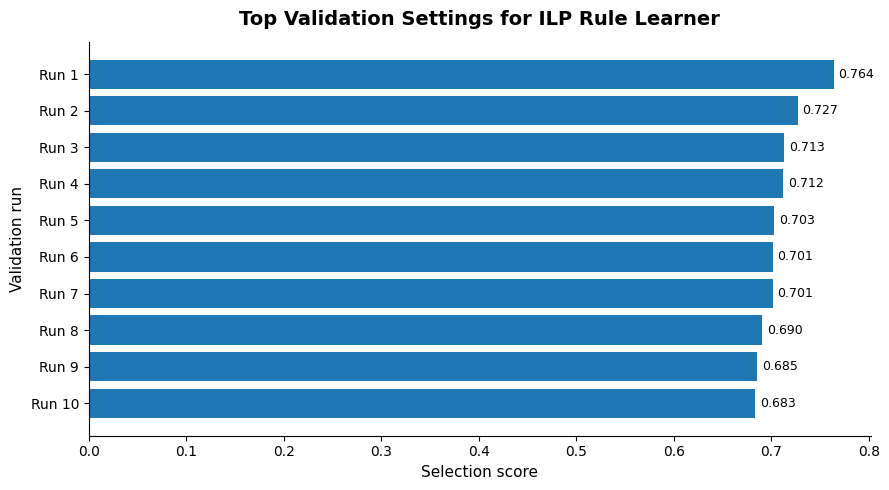

In [ ]:
# 8. Hyperparameter tuning on validation split

inner_train_sym, val_sym = train_test_split(
    train_sym,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_sym["target"]
)

inner_train_sym = inner_train_sym.reset_index(drop=True)
val_sym = val_sym.reset_index(drop=True)

inner_candidates = make_candidate_literals(inner_train_sym, metadata, min_support=10)

search_results = []

for max_rules in [6, 8, 10, 12]:
    for max_literals in [2, 3, 4]:
        for min_precision in [0.35, 0.45, 0.55]:
            for min_pos_coverage in [3, 5]:
                rules = learn_rule_set(
                    inner_train_sym,
                    inner_candidates,
                    max_rules=max_rules,
                    max_literals=max_literals,
                    min_precision=min_precision,
                    min_pos_coverage=min_pos_coverage
                )

                y_val_pred = predict_rules(val_sym, rules)
                metrics = evaluate_predictions(val_sym["target"].values, y_val_pred)

                selection_score = (
                    metrics["f1_attrition"]
                    + 0.20 * metrics["balanced_accuracy"]
                    + 0.05 * metrics["recall_attrition"]
                )

                search_results.append({
                    "max_rules": max_rules,
                    "max_literals": max_literals,
                    "min_precision": min_precision,
                    "min_pos_coverage": min_pos_coverage,
                    "n_rules": len(rules),
                    "selection_score": selection_score,
                    **metrics
                })

search_df = pd.DataFrame(search_results).sort_values(
    by="selection_score",
    ascending=False
).reset_index(drop=True)

display(search_df.head(10).round(3))

best_params = search_df.iloc[0][
    ["max_rules", "max_literals", "min_precision", "min_pos_coverage"]
].to_dict()

best_params["max_rules"] = int(best_params["max_rules"])
best_params["max_literals"] = int(best_params["max_literals"])
best_params["min_pos_coverage"] = int(best_params["min_pos_coverage"])

print("Best parameters:", best_params)

search_df.to_csv(OUTPUT_DIR / "validation_hyperparameter_search.csv", index=False)

# Visualise the top validation runs
top_search = search_df.head(10).copy()
top_search["setting"] = [f"Run {i+1}" for i in range(len(top_search))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_search["setting"][::-1], top_search["selection_score"][::-1])
ax.set_title("Top Validation Settings for ILP Rule Learner", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Selection score", fontsize=11)
ax.set_ylabel("Validation run", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_search_top10.png", dpi=300, bbox_inches="tight")
plt.show()

## Final evaluation

The final rules are trained on the full training set using the best validation settings. I then evaluate the rules on the held-out test set.

,split,accuracy,balanced_accuracy,precision_attrition,recall_attrition,f1_attrition
0,train,0.849,0.782,0.524,0.684,0.594
1,test,0.810,0.766,0.440,0.702,0.541


Classification report on held-out test set:
              precision    recall  f1-score   support

No Attrition       0.94      0.83      0.88       247
   Attrition       0.44      0.70      0.54        47

    accuracy                           0.81       294
   macro avg       0.69      0.77      0.71       294
weighted avg       0.86      0.81      0.83       294



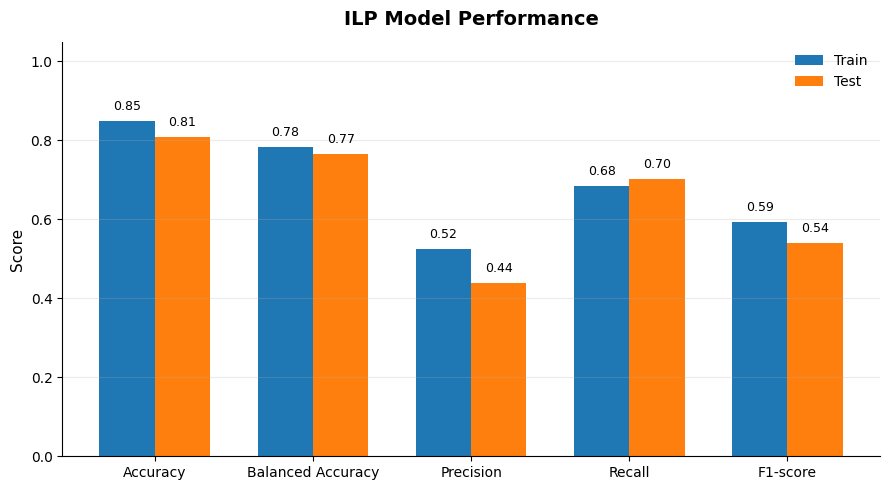

In [ ]:
# 9. Final training and held-out test evaluation

final_candidates = make_candidate_literals(train_sym, metadata, min_support=10)

final_rules = learn_rule_set(
    train_sym,
    final_candidates,
    max_rules=best_params["max_rules"],
    max_literals=best_params["max_literals"],
    min_precision=best_params["min_precision"],
    min_pos_coverage=best_params["min_pos_coverage"]
)

y_train_true = train_sym["target"].values
y_test_true = test_sym["target"].values

y_train_pred = predict_rules(train_sym, final_rules)
y_test_pred = predict_rules(test_sym, final_rules)

train_metrics = evaluate_predictions(y_train_true, y_train_pred)
test_metrics = evaluate_predictions(y_test_true, y_test_pred)

metrics_df = pd.DataFrame([
    {"split": "train", **train_metrics},
    {"split": "test", **test_metrics}
])

metrics_display = metrics_df.copy()
for col in metrics_display.columns:
    if col != "split":
        metrics_display[col] = metrics_display[col].round(3)

display(metrics_display)

print("Classification report on held-out test set:")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

metrics_df.to_csv(OUTPUT_DIR / "ilp_final_metrics.csv", index=False)

# Metrics visualisation
metric_cols = ["accuracy", "balanced_accuracy", "precision_attrition", "recall_attrition", "f1_attrition"]
plot_df = metrics_df.set_index("split")[metric_cols].T
plot_df.index = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1-score"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df.index))
width = 0.35

train_bars = ax.bar(x - width/2, plot_df["train"], width, label="Train")
test_bars = ax.bar(x + width/2, plot_df["test"], width, label="Test")

ax.set_title("ILP Model Performance", fontsize=14, fontweight="bold", pad=12)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=10)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

for bars in [train_bars, test_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

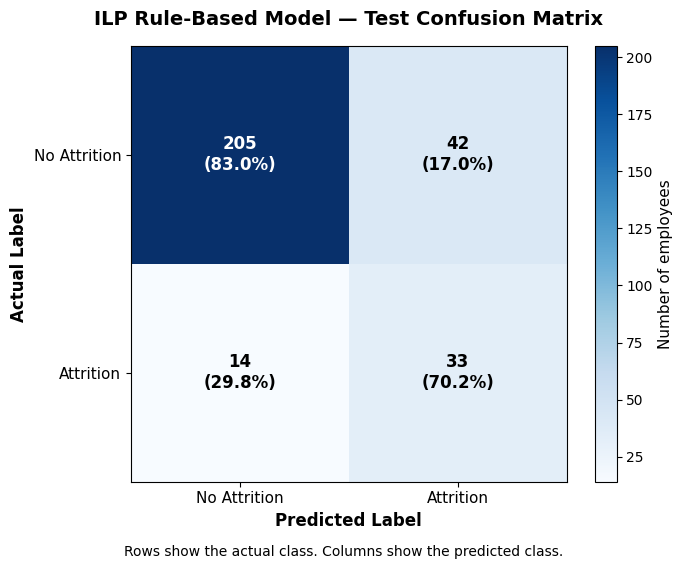

Confusion matrix:
[[205  42]
 [ 14  33]]


In [ ]:
# 10. Confusion matrix

cm = confusion_matrix(y_test_true, y_test_pred)
class_labels = ["No Attrition", "Attrition"]

with np.errstate(divide="ignore", invalid="ignore"):
    cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
    cm_percent = np.nan_to_num(cm_percent)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

ax.set_title("ILP Rule-Based Model — Test Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual Label", fontsize=12, fontweight="bold")

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, fontsize=11)
ax.set_yticklabels(class_labels, fontsize=11)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if cm[i, j] > threshold else "black"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
            fontweight="bold"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of employees", fontsize=11)

plt.figtext(
    0.5, -0.02,
    "Rows show the actual class. Columns show the predicted class.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix:")
print(cm)

## ROC curve

I also added a ROC curve using rule-based risk scores. Since the ILP model outputs rules rather than probabilities, the score is based on the strength of the matched rules on the training data. This gives a cleaner way to check how well the rules separate attrition and non-attrition cases.

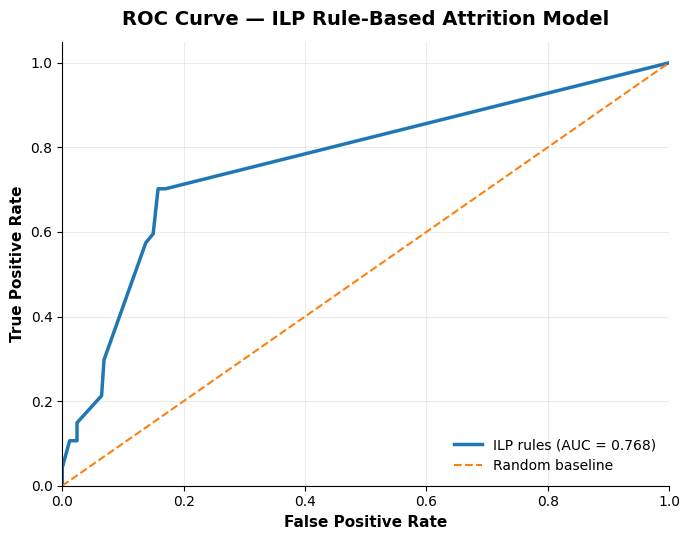

,metric,test_score
0,ROC AUC,0.768


In [ ]:
# 10b. ROC curve for the ILP rule model

# A normal classifier often gives probabilities. This ILP model gives rules instead.
# So, I create a simple risk score from the rules that each employee matches.
def predict_rule_scores(data, rules, reference_data):
    scores = np.zeros(len(data), dtype=float)
    matched_rule_count = np.zeros(len(data), dtype=int)

    for rule in rules:
        stats = rule_stats(reference_data, rule)
        rule_precision = stats["precision"]
        rule_recall = stats["positive_recall"]

        # Rule strength favours precise rules but still gives some weight to coverage.
        rule_strength = (0.75 * rule_precision) + (0.25 * rule_recall)

        mask = covers_rule(data, rule)
        scores[mask] = np.maximum(scores[mask], rule_strength)
        matched_rule_count[mask] += 1

    # Small boost if more than one rule matches the same employee.
    if matched_rule_count.max() > 0:
        scores = np.minimum(1.0, scores + (0.03 * matched_rule_count))

    return scores


y_test_scores = predict_rule_scores(test_sym, final_rules, train_sym)
fpr, tpr, thresholds = roc_curve(y_test_true, y_test_scores)
roc_auc = roc_auc_score(y_test_true, y_test_scores)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr, tpr, linewidth=2.5, label=f"ILP rules (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random baseline")

ax.set_title("ROC Curve — ILP Rule-Based Attrition Model", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("False Positive Rate", fontsize=11, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=11, fontweight="bold")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

roc_summary = pd.DataFrame({
    "metric": ["ROC AUC"],
    "test_score": [roc_auc]
})

roc_summary.to_csv(OUTPUT_DIR / "roc_auc_score.csv", index=False)
display(roc_summary.round(3))


## Learned rules

The rules below are the main output of the ILP model. They are useful because they show the conditions that led the model to predict attrition.

Learned ILP rules
Rule 1:
IF JobLevel = level 1 AND OverTime = yes THEN Attrition = Yes
attrition(E) :- joblevel(E, level_1), overtime(E, yes).
Train stats: {'positive_covered': 60, 'negative_covered': 56, 'total_covered': 116, 'precision': 0.5172413793103449, 'positive_recall': 0.3157894736842105}
Test stats: {'positive_covered': 22, 'negative_covered': 18, 'total_covered': 40, 'precision': 0.55, 'positive_recall': 0.46808510638297873}
--------------------------------------------------------------------------------
Rule 2:
IF StockOptionLevel = level 0 AND Department Sales = yes AND OverTime = yes THEN Attrition = Yes
attrition(E) :- stockoptionlevel(E, level_0), department_sales(E, yes), overtime(E, yes).
Train stats: {'positive_covered': 26, 'negative_covered': 21, 'total_covered': 47, 'precision': 0.5531914893617021, 'positive_recall': 0.1368421052631579}
Test stats: {'positive_covered': 10, 'negative_covered': 3, 'total_covered': 13, 'precision': 0.7692307692307693, 'positive_reca

,rule_number,text_rule,test_positive_covered,test_negative_covered,test_precision,test_positive_recall
0,1,IF JobLevel = level 1 AND OverTime = yes THEN ...,22,18,0.550,0.468
1,2,IF StockOptionLevel = level 0 AND Department S...,10,3,0.769,0.213
2,3,IF YearsAtCompany = very low AND Age = very lo...,7,10,0.412,0.149
3,4,IF EnvironmentSatisfaction = level 1 AND JobIn...,2,2,0.500,0.043
4,5,IF BusinessTravel Travel Frequently = yes AND ...,3,4,0.429,0.064
5,6,IF EnvironmentSatisfaction = level 1 AND Educa...,2,3,0.400,0.043
6,7,IF JobSatisfaction = level 1 AND StockOptionLe...,0,0,0.000,0.000
7,8,IF DistanceFromHome = high AND YearsAtCompany ...,1,4,0.200,0.021


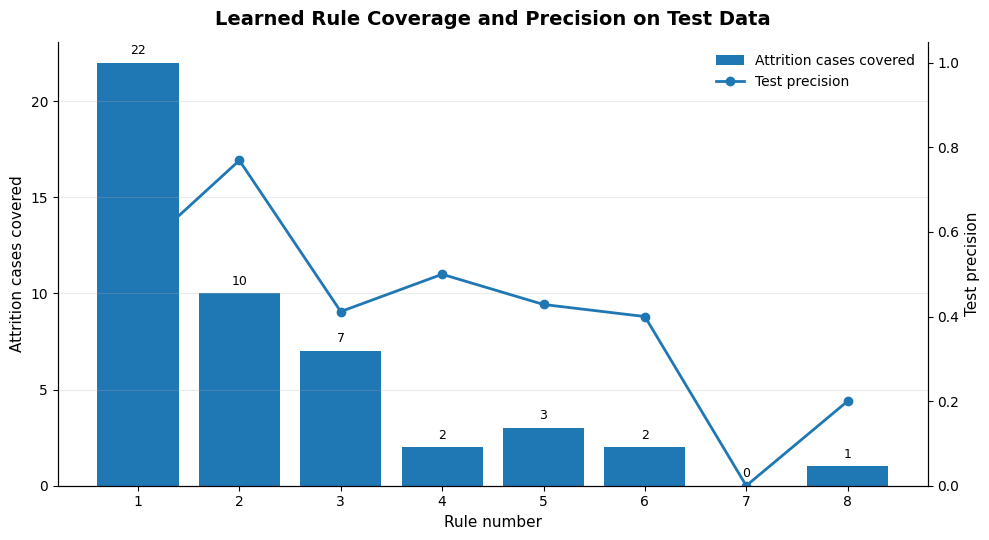

In [ ]:
# 11. Print, visualise, and save learned rules

def pretty_feature_name(col):
    return col.replace("_", " ")


def pretty_value(value):
    return str(value).replace("_", " ")


def rule_to_text(rule):
    conditions = [f"{pretty_feature_name(col)} = {pretty_value(value)}" for col, value in rule]
    return "IF " + " AND ".join(conditions) + " THEN Attrition = Yes"


def rule_to_prolog(rule):
    body = []
    for col, value in rule:
        pred = clean_predicate_name(col)
        atom = clean_atom(value)
        body.append(f"{pred}(E, {atom})")
    return "attrition(E) :- " + ", ".join(body) + "."


rule_rows = []

print("Learned ILP rules")
print("=" * 80)

for i, rule in enumerate(final_rules, start=1):
    train_stats = rule_stats(train_sym, rule)
    test_stats = rule_stats(test_sym, rule)

    text_rule = rule_to_text(rule)
    prolog_rule = rule_to_prolog(rule)

    print(f"Rule {i}:")
    print(text_rule)
    print(prolog_rule)
    print("Train stats:", train_stats)
    print("Test stats:", test_stats)
    print("-" * 80)

    rule_rows.append({
        "rule_number": i,
        "text_rule": text_rule,
        "prolog_rule": prolog_rule,
        "train_positive_covered": train_stats["positive_covered"],
        "train_negative_covered": train_stats["negative_covered"],
        "train_precision": train_stats["precision"],
        "train_positive_recall": train_stats["positive_recall"],
        "test_positive_covered": test_stats["positive_covered"],
        "test_negative_covered": test_stats["negative_covered"],
        "test_precision": test_stats["precision"],
        "test_positive_recall": test_stats["positive_recall"]
    })

rules_df = pd.DataFrame(rule_rows)

display_cols = [
    "rule_number", "text_rule", "test_positive_covered",
    "test_negative_covered", "test_precision", "test_positive_recall"
]

rules_display = rules_df[display_cols].copy()
for col in ["test_precision", "test_positive_recall"]:
    rules_display[col] = rules_display[col].round(3)

display(rules_display)

rules_df.to_csv(OUTPUT_DIR / "learned_rules_table.csv", index=False)

with open(OUTPUT_DIR / "learned_rules.txt", "w") as f:
    for row in rule_rows:
        f.write(f"Rule {row['rule_number']}: {row['text_rule']}\n")
        f.write(f"{row['prolog_rule']}\n\n")

with open(OUTPUT_DIR / "learned_rules.pl", "w") as f:
    for row in rule_rows:
        f.write(f"% Rule {row['rule_number']}\n")
        f.write(row["prolog_rule"] + "\n\n")

# Rule-level visualisation
if not rules_df.empty:
    fig, ax1 = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(rules_df))

    bars = ax1.bar(x, rules_df["test_positive_covered"], label="Attrition cases covered")
    ax1.set_ylabel("Attrition cases covered", fontsize=11)
    ax1.set_xlabel("Rule number", fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels(rules_df["rule_number"].astype(str))
    ax1.spines["top"].set_visible(False)
    ax1.grid(axis="y", alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(x, rules_df["test_precision"], marker="o", linewidth=2, label="Test precision")
    ax2.set_ylabel("Test precision", fontsize=11)
    ax2.set_ylim(0, 1.05)
    ax2.spines["top"].set_visible(False)

    ax1.set_title("Learned Rule Coverage and Precision on Test Data", fontsize=14, fontweight="bold", pad=12)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.3, f"{int(height)}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rule_coverage_precision.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# 12. Save test predictions

test_predictions = test_df.copy()
test_predictions["ILP_Predicted_Attrition"] = y_test_pred
test_predictions["ILP_Predicted_Label"] = np.where(y_test_pred == 1, "Yes", "No")

test_predictions.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

display(test_predictions[[TARGET_COL, "ILP_Predicted_Attrition", "ILP_Predicted_Label"]].head())
print("Saved test predictions.")

,Attrition,ILP_Predicted_Attrition,ILP_Predicted_Label
0,0,0,No
1,0,0,No
2,0,0,No
3,0,0,No
4,1,1,Yes


Saved test predictions.


## Prolog/Aleph-style files

Here I create the ILP files in a Prolog/Aleph-style format. The .b file stores the employee facts and rule settings. The .f and .n files store the positive and negative attrition examples.

I included this so the IBM-HR attrition task is also shown in a standard ILP format, not only through the Python rule learner.

In [ ]:
# 13. Export Prolog/Aleph-style files

PROLOG_DIR = OUTPUT_DIR / "prolog_aleph_files"
PROLOG_DIR.mkdir(exist_ok=True)


def employee_id(prefix, i):
    return f"{prefix}_{i:04d}"


def prolog_fact(predicate, emp, value):
    return f"{predicate}({emp}, {clean_atom(value)})."


def write_background_file(train_sym, test_sym, metadata, filepath):
    feature_cols = [c for c in train_sym.columns if c != "target"]

    with open(filepath, "w") as f:
        f.write("% IBM HR Attrition ILP background knowledge\n")
        f.write("% Target predicate: attrition(Employee).\n\n")

        f.write(":- modeh(1, attrition(+employee)).\n\n")

        for col in feature_cols:
            pred = clean_predicate_name(col)
            f.write(f":- modeb(*, {pred}(+employee, #value)).\n")

        f.write("\n")

        for col in feature_cols:
            pred = clean_predicate_name(col)
            f.write(f":- determination(attrition/1, {pred}/2).\n")

        f.write("\n% Training background facts\n\n")

        for i, row in train_sym.reset_index(drop=True).iterrows():
            emp = employee_id("tr", i + 1)
            f.write(f"employee({emp}).\n")
            for col in feature_cols:
                pred = clean_predicate_name(col)
                f.write(prolog_fact(pred, emp, row[col]) + "\n")
            f.write("\n")

        f.write("\n% Test background facts, without labels in training examples\n\n")

        for i, row in test_sym.reset_index(drop=True).iterrows():
            emp = employee_id("te", i + 1)
            f.write(f"employee({emp}).\n")
            for col in feature_cols:
                pred = clean_predicate_name(col)
                f.write(prolog_fact(pred, emp, row[col]) + "\n")
            f.write("\n")


def write_examples_file(sym_df, filepath, positive=True, prefix="tr"):
    with open(filepath, "w") as f:
        for i, row in sym_df.reset_index(drop=True).iterrows():
            is_positive = int(row["target"]) == 1
            if is_positive == positive:
                emp = employee_id(prefix, i + 1)
                f.write(f"attrition({emp}).\n")


write_background_file(train_sym, test_sym, metadata, PROLOG_DIR / "ibm_hr_attrition.b")
write_examples_file(train_sym, PROLOG_DIR / "ibm_hr_attrition.f", positive=True, prefix="tr")
write_examples_file(train_sym, PROLOG_DIR / "ibm_hr_attrition.n", positive=False, prefix="tr")
write_examples_file(test_sym, PROLOG_DIR / "ibm_hr_attrition_test.f", positive=True, prefix="te")
write_examples_file(test_sym, PROLOG_DIR / "ibm_hr_attrition_test.n", positive=False, prefix="te")

readme = f"""
IBM HR Attrition — Prolog/Aleph ILP Files
========================================

Files:
- ibm_hr_attrition.b       Background knowledge + mode declarations
- ibm_hr_attrition.f       Positive training examples
- ibm_hr_attrition.n       Negative training examples
- ibm_hr_attrition_test.f  Positive test examples for external checking
- ibm_hr_attrition_test.n  Negative test examples for external checking

Training positives: {(train_sym["target"] == 1).sum()}
Training negatives: {(train_sym["target"] == 0).sum()}
Test positives: {(test_sym["target"] == 1).sum()}
Test negatives: {(test_sym["target"] == 0).sum()}

Important:
This notebook runs a Python FOIL-style ILP learner and exports equivalent Prolog/Aleph task files.
Do not say Aleph was executed unless these files are actually run in an Aleph environment.
""".strip()

with open(PROLOG_DIR / "README_ALEPH_FILES.txt", "w") as f:
    f.write(readme)

zip_path = OUTPUT_DIR / "ibm_hr_attrition_prolog_files.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for path in PROLOG_DIR.iterdir():
        z.write(path, arcname=path.name)

print("Generated Prolog/Aleph files:")
for path in sorted(PROLOG_DIR.iterdir()):
    print("-", path)

print("\nZipped Prolog files to:", zip_path)


Generated Prolog/Aleph files:
- ilp_outputs/prolog_aleph_files/README_ALEPH_FILES.txt
- ilp_outputs/prolog_aleph_files/ibm_hr_attrition.b
- ilp_outputs/prolog_aleph_files/ibm_hr_attrition.f
- ilp_outputs/prolog_aleph_files/ibm_hr_attrition.n
- ilp_outputs/prolog_aleph_files/ibm_hr_attrition_test.f
- ilp_outputs/prolog_aleph_files/ibm_hr_attrition_test.n

Zipped Prolog files to: ilp_outputs/ibm_hr_attrition_prolog_files.zip


## Save outputs

This last step zips the notebook outputs so they are easier to download or submit with the model notebook.

In [ ]:
# 14. Zip the model outputs

zip_all_path = Path("ibm_hr_ilp_outputs_with_roc.zip")

with zipfile.ZipFile(zip_all_path, "w", zipfile.ZIP_DEFLATED) as z:
    for path in OUTPUT_DIR.rglob("*"):
        if path.is_file():
            z.write(path, arcname=str(path.relative_to(OUTPUT_DIR.parent)))

print("Zipped model outputs to:", zip_all_path.resolve())
print("Notebook completed successfully.")

Zipped model outputs to: /content/ibm_hr_ilp_outputs_with_roc.zip
Notebook completed successfully.
